## 1 - Install Packages

In [1]:
# ============================================================
# Cell 1: Install packages (Colab-safe)
# ============================================================
!pip -q install --upgrade pip
!pip -q install pandas matplotlib scikit-learn networkx torch torchvision torchaudio
!pip -q install torch-geometric


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.8 MB/s eta 0:00:00


## 2 - imports and configs

In [2]:
# ============================================================
# Cell 2: Imports, global config, and output folders
# ============================================================
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.utils import (
    to_undirected,
    remove_self_loops,
    coalesce,
    degree,
    homophily,
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Global experiment config
# -----------------------------
DATASET_NAMES = ["DE", "EN", "ES", "FR", "PT", "RU"]
SEEDS = [0, 1, 2, 3, 4]   # standardized to 5 seeds across MLP/GCN/SAGE/GAT

# Same headline/selection metric as the MLP notebook.
MAIN_METRIC = "macro_f1"
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

DEFAULT_CONFIG = {
    "hidden_dim": 64,
    "num_layers": 2,       # number of propagation rounds after feature embedding
    "dropout": 0.5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 30
}

# Ablation grids, matched in spirit to the MLP notebook.
ABLATION_GRID = {
    "hidden_dim": [32, 64, 128],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.2, 0.5]
}

# -----------------------------
# Paths
# -----------------------------
ROOT_OUTPUT_DIR = "outputs"
METRICS_DIR = os.path.join(ROOT_OUTPUT_DIR, "metrics")
FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT_OUTPUT_DIR, "models")
SPLITS_DIR = os.path.join(ROOT_OUTPUT_DIR, "splits")

for path in [ROOT_OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR]:
    os.makedirs(path, exist_ok=True)

print("Output directory:", ROOT_OUTPUT_DIR)
print("Datasets:", DATASET_NAMES)
print("Seeds:", SEEDS)
print("Main metric (selection + headline):", MAIN_METRIC)
print("Default config:", DEFAULT_CONFIG)


Torch version: 2.10.0+cpu
CUDA available: False
Using device: cpu
Output directory: outputs
Datasets: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Main metric (selection + headline): macro_f1
Default config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'max_epochs': 200, 'patience': 30}


## 3 - utilities

In [3]:
# ============================================================
# Cell 3: Utility functions
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / exp_vals.sum(axis=1, keepdims=True)

def compute_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    probs = softmax_numpy(logits)
    y_pred = probs.argmax(axis=1)

    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["f1"] = float(f1_score(y_true, y_pred, average="binary"))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    # ROC-AUC only if both classes are present
    if len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, probs[:, 1]))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20
) -> Dict[str, np.ndarray]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    n = len(y)
    indices = np.arange(n)

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        stratify=y
    )

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx, _, _ = train_test_split(
        temp_idx,
        y_temp,
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        stratify=y_temp
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx)
    }

def make_mask(indices: np.ndarray, n: int) -> torch.Tensor:
    mask = torch.zeros(n, dtype=torch.bool)
    mask[torch.tensor(indices, dtype=torch.long)] = True
    return mask

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1

    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def plot_training_curves(history: Dict[str, List[float]], title: str, save_path: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_bar_with_error(
    df: pd.DataFrame,
    metric_col: str,
    std_col: str,
    title: str,
    save_path: str
) -> None:
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    plt.bar(x, df[metric_col].values, yerr=df[std_col].values, capsize=5)
    plt.xticks(x, df["dataset"].values)
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


## 4 - load twitch

In [4]:
# ============================================================
# Cell 4: Download Twitch MUSAE files directly
# ============================================================
import os
import json
import urllib.request
import urllib.error

RAW_TWITCH_DIR = "data/twitch_manual_direct"
os.makedirs(RAW_TWITCH_DIR, exist_ok=True)

# Notebook names -> raw domain names used by public MUSAE mirrors
DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

# Public raw file mirror
BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading {url}")
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(f"Failed to download {url}\nOriginal error: {repr(e)}")

def load_direct_domain(domain_code: str):
    domain_dir = os.path.join(RAW_TWITCH_DIR, domain_code)
    os.makedirs(domain_dir, exist_ok=True)

    edges_path = os.path.join(domain_dir, f"musae_{domain_code}_edges.csv")
    features_path = os.path.join(domain_dir, f"musae_{domain_code}_features.json")
    target_path = os.path.join(domain_dir, f"musae_{domain_code}_target.csv")

    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_edges.csv", edges_path)
    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_features.json", features_path)
    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_target.csv", target_path)

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    required_cols = {"id", "new_id", "mature"}
    missing = required_cols - set(target_df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns {missing} in {target_path}. "
            f"Found columns: {list(target_df.columns)}"
        )

    # Sort by new_id so feature rows line up with JSON keys
    target_df = target_df.sort_values("new_id").reset_index(drop=True)

    original_ids = target_df["id"].astype(int).tolist()
    new_ids = target_df["new_id"].astype(int).tolist()

    original_id_to_row = {oid: i for i, oid in enumerate(original_ids)}
    new_id_to_row = {nid: i for i, nid in enumerate(new_ids)}

    num_nodes = len(target_df)

    # -----------------------------
    # Features keyed by new_id
    # -----------------------------
    feature_keys_int = set(int(k) for k in features_dict.keys())
    if not set(new_ids).issubset(feature_keys_int):
        raise ValueError(
            f"Feature JSON keys do not cover all new_id values for domain {domain_code}."
        )

    max_feat_index = -1
    for nid in new_ids:
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            max_feat_index = max(max_feat_index, max(feat_list))

    num_features = max_feat_index + 1
    x_np = np.zeros((num_nodes, num_features), dtype=np.float32)

    for row_idx, nid in enumerate(new_ids):
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            x_np[row_idx, np.asarray(feat_list, dtype=np.int64)] = 1.0

    # -----------------------------
    # Labels
    # -----------------------------
    y_np = target_df["mature"].astype(int).to_numpy(dtype=np.int64)

    # -----------------------------
    # Edges
    # Try both original-id indexing and new_id indexing.
    # -----------------------------
    edge_cols_lower = {c.lower(): c for c in edges_df.columns}
    if "from" in edge_cols_lower and "to" in edge_cols_lower:
        src_col = edge_cols_lower["from"]
        dst_col = edge_cols_lower["to"]
    else:
        if edges_df.shape[1] < 2:
            raise ValueError(f"Edge file {edges_path} has fewer than 2 columns.")
        src_col = edges_df.columns[0]
        dst_col = edges_df.columns[1]

    src_raw = edges_df[src_col].astype(int).to_numpy()
    dst_raw = edges_df[dst_col].astype(int).to_numpy()

    def build_edges(id_to_row):
        edge_pairs = []
        missing_count = 0
        for s, t in zip(src_raw, dst_raw):
            if s in id_to_row and t in id_to_row:
                edge_pairs.append((id_to_row[s], id_to_row[t]))
            else:
                missing_count += 1
        return edge_pairs, missing_count

    # First try original Twitch ids
    edge_pairs_orig, missing_orig = build_edges(original_id_to_row)

    # Then try new_id indexing
    edge_pairs_new, missing_new = build_edges(new_id_to_row)

    if len(edge_pairs_orig) > 0:
        edge_pairs = edge_pairs_orig
        missing_count = missing_orig
        edge_id_mode = "original_id"
    elif len(edge_pairs_new) > 0:
        edge_pairs = edge_pairs_new
        missing_count = missing_new
        edge_id_mode = "new_id"
    else:
        raise ValueError(
            f"No valid edges remained after trying both original id and new_id alignment "
            f"for domain {domain_code}."
        )

    edge_index_np = np.asarray(edge_pairs, dtype=np.int64).T

    # Remove self-loops if any
    keep = edge_index_np[0] != edge_index_np[1]
    edge_index_np = edge_index_np[:, keep]

    # Undirected summary
    edge_pairs_sorted = np.sort(edge_index_np.T, axis=1)
    unique_undirected_edges = np.unique(edge_pairs_sorted, axis=0)
    num_edges_undirected = int(unique_undirected_edges.shape[0])

    row = {
        "num_nodes": num_nodes,
        "num_edges_directed_count": int(edge_index_np.shape[1]),
        "num_edges_undirected_approx": num_edges_undirected,
        "num_features": int(x_np.shape[1]),
        "class_0_count": int((y_np == 0).sum()),
        "class_1_count": int((y_np == 1).sum()),
        "class_1_fraction": float((y_np == 1).mean()),
        "feature_mean": float(x_np.mean()),
        "feature_std": float(x_np.std()),
        "density_undirected_approx": graph_density_undirected(num_nodes, num_edges_undirected),
        "dropped_edges_due_to_id_mismatch": int(missing_count),
        "edge_id_mode": edge_id_mode,
        **degree_stats_from_edge_index(edge_index_np, num_nodes),
    }

    return x_np, y_np, edge_index_np, row

def build_pyg_data(x_np: np.ndarray, y_np: np.ndarray, edge_index_np: np.ndarray, graph_name: str) -> Data:
    x = torch.tensor(x_np, dtype=torch.float)
    y = torch.tensor(y_np, dtype=torch.long)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    edge_index, _ = remove_self_loops(edge_index)
    edge_index = to_undirected(edge_index, num_nodes=x.shape[0])
    edge_index = coalesce(edge_index)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.graph_name = graph_name
    return data

def make_sparse_row_norm_adj(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    # Row-normalized adjacency without self-loops. This keeps ego information separate,
    # which is the point of the H2GCN-style baseline.
    edge_index, _ = remove_self_loops(edge_index)
    edge_index = coalesce(edge_index, num_nodes=num_nodes)
    row, col = edge_index[0], edge_index[1]
    deg_row = degree(row, num_nodes=num_nodes, dtype=torch.float)
    values = 1.0 / deg_row[row].clamp(min=1.0)
    adj = torch.sparse_coo_tensor(edge_index, values, (num_nodes, num_nodes))
    return adj.coalesce()

dataset_objects = {}
dataset_data = {}
dataset_summary_rows = []

for name in DATASET_NAMES:
    raw_code = DOMAIN_MAP[name]
    print(f"Loading Twitch dataset: notebook={name}, raw_domain={raw_code}")

    x_np, y_np, edge_index_np, row = load_direct_domain(raw_code)
    data_obj = build_pyg_data(x_np, y_np, edge_index_np, graph_name=name)

    try:
        edge_hom = float(homophily(data_obj.edge_index, data_obj.y, method="edge"))
    except Exception:
        edge_hom = np.nan

    row["dataset"] = name
    row["edge_homophily"] = edge_hom
    row["num_edges_after_undirected"] = int(data_obj.edge_index.shape[1])

    dataset_objects[name] = None
    dataset_data[name] = {
        "data_obj": data_obj,
        "x_np": x_np,
        "y_np": y_np,
        "edge_index_np": edge_index_np
    }
    dataset_summary_rows.append(row)

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
display(dataset_summary_df)

dataset_summary_path = os.path.join(METRICS_DIR, "h2gcn_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)

print(f"Saved dataset summary to: {dataset_summary_path}")


Loading Twitch dataset: notebook=DE, raw_domain=DE
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
Loading Twitch dataset: notebook=ES, raw_domain=ES
Loading Twitch dataset: notebook=FR, raw_domain=FR
Loading Twitch dataset: notebook=PT, raw_domain=PTBR
Loading Twitch dataset: notebook=RU, raw_domain=RU


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset,edge_homophily,num_edges_after_undirected
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE,0.632234,306276
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN,0.555996,70648
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES,0.579991,118764
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR,0.559450,225332
4,1912,31299,31299,3169,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT,0.570849,62598
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU,0.617628,74608


Saved dataset summary to: outputs/metrics/h2gcn_dataset_summary.csv


## 5 - dataset and splits

In [5]:
# ============================================================
# Cell 5: Train/val/test splits
# ============================================================
all_splits = {}
split_rows = []

for name in DATASET_NAMES:
    y_np = dataset_data[name]["y_np"]
    n = len(y_np)
    all_splits[name] = {}

    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO
        )
        all_splits[name][seed] = splits

        split_rows.append({
            "dataset": name,
            "seed": seed,
            "n_total": n,
            "n_train": len(splits["train"]),
            "n_val": len(splits["val"]),
            "n_test": len(splits["test"]),
            "train_pos_frac": float(y_np[splits["train"]].mean()),
            "val_pos_frac": float(y_np[splits["val"]].mean()),
            "test_pos_frac": float(y_np[splits["test"]].mean())
        })

        save_json(
            {k: v.tolist() for k, v in splits.items()},
            os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        )

splits_df = pd.DataFrame(split_rows).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(splits_df.head(12))

splits_df.to_csv(os.path.join(METRICS_DIR, "h2gcn_split_summary.csv"), index=False)
print("Saved split metadata.")


,dataset,seed,n_total,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac
0,DE,0,9498,5698,1900,1900,0.604598,0.604737,0.604211
1,DE,1,9498,5698,1900,1900,0.604598,0.604211,0.604737
2,DE,2,9498,5698,1900,1900,0.604598,0.604737,0.604211
3,DE,3,9498,5698,1900,1900,0.604598,0.604737,0.604211
4,DE,4,9498,5698,1900,1900,0.604598,0.604737,0.604211
5,EN,0,7126,4275,1425,1426,0.545497,0.545965,0.545582
6,EN,1,7126,4275,1425,1426,0.545497,0.545965,0.545582
7,EN,2,7126,4275,1425,1426,0.545497,0.545965,0.545582
8,EN,3,7126,4275,1425,1426,0.545497,0.545965,0.545582
9,EN,4,7126,4275,1425,1426,0.545497,0.545965,0.545582


Saved split metadata.


## 5b. Cross-notebook split consistency check

This cell verifies that the splits we just generated are identical to splits saved by the GCN / GraphSAGE / GAT / MLP notebooks for the same `(dataset, seed)`. If the JSONs from the other notebooks aren't present in this Colab session, the cell prints a warning and is a no-op. To enable the check, copy other notebooks' `outputs/splits/*.json` into one of the candidate locations below.


In [6]:
# ============================================================
# Cell 5b: Cross-notebook split consistency check
# ============================================================
# Compares the splits generated above against splits saved by the
# MLP / GCN / SAGE / GAT notebooks. Helps verify the "same splits across all
# models" claim in the report.
import json as _json

EXTERNAL_SPLIT_DIRS = [
    "/content/outputs/splits",                          # other notebooks dumped to /content/outputs
    "outputs/splits",                                   # current local output folder
    "/content/drive/MyDrive/STAT175_FP/outputs/splits", # common shared Drive folder, if used
]

def _load_split_json(path):
    with open(path, "r") as f:
        obj = _json.load(f)
    return {k: np.asarray(v, dtype=np.int64) for k, v in obj.items()}

def _same_splits(a, b):
    return all(np.array_equal(a[k], b[k]) for k in ["train", "val", "test"])

checked = 0
mismatches = []

for dataset_name in DATASET_NAMES:
    for seed in SEEDS:
        current = all_splits[dataset_name][seed]
        filename = f"{dataset_name}_seed{seed}_splits.json"

        found_paths = []
        for split_dir in EXTERNAL_SPLIT_DIRS:
            path = os.path.join(split_dir, filename)
            if os.path.exists(path):
                found_paths.append(path)

        # If only the current notebook's just-saved file exists, this is still a valid check.
        for path in found_paths:
            other = _load_split_json(path)
            checked += 1
            if not _same_splits(current, other):
                mismatches.append((dataset_name, seed, path))

if checked == 0:
    print("No external split JSONs found to compare against.")
elif len(mismatches) == 0:
    print(f"Split check passed for {checked} split files.")
else:
    print("WARNING: split mismatches found:")
    for item in mismatches:
        print(item)


Split check passed for 60 split files.


## 6 - H2GCN model

In [7]:
# ============================================================
# Cell 6: H2GCN-style model definition
# ============================================================
class H2GCNNet(nn.Module):
    """
    Lightweight H2GCN-style node classifier.

    The model keeps ego information separate from propagated neighborhood
    information. It embeds node features once, repeatedly propagates that
    embedding through the row-normalized adjacency, concatenates the ego and
    higher-order representations, and then classifies.
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 2,
        dropout: float = 0.5
    ):
        super().__init__()
        assert num_layers >= 1
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout = dropout

        self.embed = nn.Linear(input_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim * (num_layers + 1), output_dim)

    def forward(self, x: torch.Tensor, adj_norm: torch.Tensor):
        x = F.dropout(x, p=self.dropout, training=self.training)
        h0 = F.relu(self.embed(x))

        reps = [h0]
        h = h0
        for _ in range(self.num_layers):
            h = torch.sparse.mm(adj_norm, h)
            reps.append(h)

        z = torch.cat(reps, dim=1)
        z = F.dropout(z, p=self.dropout, training=self.training)
        logits = self.classifier(z)
        return z, logits

print("H2GCN-style model class defined.")


H2GCN-style model class defined.


## 7 - training and eval functions

In [8]:
# ============================================================
# Cell 7: Training and evaluation functions
# ============================================================
@dataclass
class RunArtifacts:
    history: Dict[str, List[float]]
    best_state_dict: Dict
    best_epoch: int

def evaluate_logits(y_true: np.ndarray, logits: np.ndarray):
    loss = F.cross_entropy(
        torch.tensor(logits, dtype=torch.float),
        torch.tensor(y_true, dtype=torch.long)
    ).item()
    metrics = compute_metrics(y_true, logits)
    return loss, metrics

def train_one_run(
    data_obj: Data,
    splits: Dict[str, np.ndarray],
    seed: int,
    config: Dict,
    dataset_name: str,
    run_name: str,
    save_training_curve: bool = True
) -> Dict:
    set_global_seed(seed)

    data = copy.deepcopy(data_obj).to(DEVICE)
    n = data.num_nodes

    train_mask = make_mask(splits["train"], n).to(DEVICE)
    val_mask = make_mask(splits["val"], n).to(DEVICE)
    test_mask = make_mask(splits["test"], n).to(DEVICE)

    adj_norm = make_sparse_row_norm_adj(data.edge_index.detach().cpu(), num_nodes=n).to(DEVICE)

    input_dim = data.x.shape[1]
    output_dim = int(data.y.max().item()) + 1

    model = H2GCNNet(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        output_dim=output_dim,
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_macro_f1": [],
        "val_macro_f1": [],
        "train_f1": [],
        "val_f1": []
    }

    best_val_metric = -np.inf
    best_epoch = -1
    best_state_dict = copy.deepcopy(model.state_dict())
    patience_counter = 0
    t0 = time.time()

    for epoch in range(config["max_epochs"]):
        model.train()
        optimizer.zero_grad()
        _, logits = model(data.x, adj_norm)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, logits_eval = model(data.x, adj_norm)

        logits_np = logits_eval.detach().cpu().numpy()
        y_np = data.y.detach().cpu().numpy()

        train_loss, train_metrics = evaluate_logits(y_np[splits["train"]], logits_np[splits["train"]])
        val_loss, val_metrics = evaluate_logits(y_np[splits["val"]], logits_np[splits["val"]])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        current_val_metric = val_metrics[MAIN_METRIC]

        if current_val_metric > best_val_metric:
            best_val_metric = current_val_metric
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    elapsed = time.time() - t0

    # Final evaluation with best params
    model.load_state_dict(best_state_dict)
    model.eval()
    with torch.no_grad():
        emb, logits = model(data.x, adj_norm)

    logits_np = logits.detach().cpu().numpy()
    y_np = data.y.detach().cpu().numpy()

    train_loss, train_metrics = evaluate_logits(y_np[splits["train"]], logits_np[splits["train"]])
    val_loss, val_metrics = evaluate_logits(y_np[splits["val"]], logits_np[splits["val"]])
    test_loss, test_metrics = evaluate_logits(y_np[splits["test"]], logits_np[splits["test"]])

    result = {
        "dataset": dataset_name,
        "seed": seed,
        "run_name": run_name,
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_epochs": config["max_epochs"],
        "patience": config["patience"],
        "best_epoch": best_epoch,
        "elapsed_seconds": elapsed,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "history": history,
        "best_state_dict_path": None
    }

    model_path = os.path.join(MODELS_DIR, f"{dataset_name}_{run_name}_seed{seed}.pt")
    torch.save(best_state_dict, model_path)
    result["best_state_dict_path"] = model_path

    if save_training_curve:
        curve_path = os.path.join(FIGURES_DIR, f"{dataset_name}_{run_name}_seed{seed}_training_curve.png")
        plot_training_curves(
            history,
            title=f"{dataset_name} | {run_name} | seed={seed}",
            save_path=curve_path
        )

    return result

print("Training utilities ready.")


Training utilities ready.


## 8 - main H2GCN baseline run

Running default H2GCN on dataset: DE
  Seed 0 ...


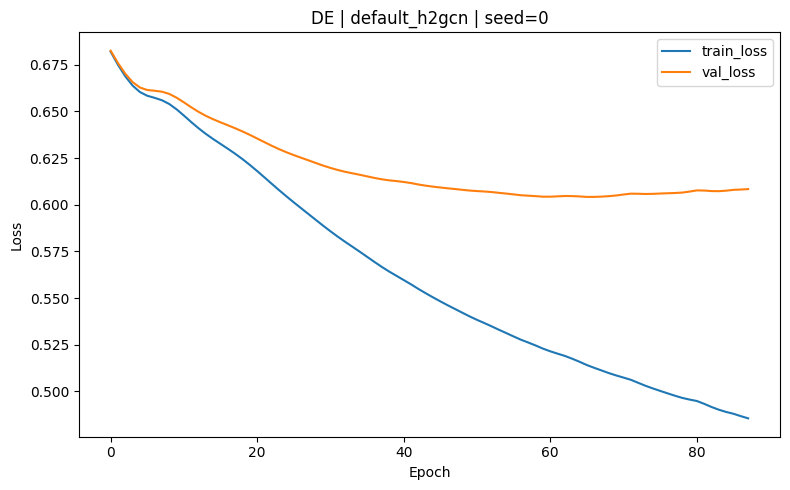

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default H2GCN on dataset: EN
  Seed 0 ...


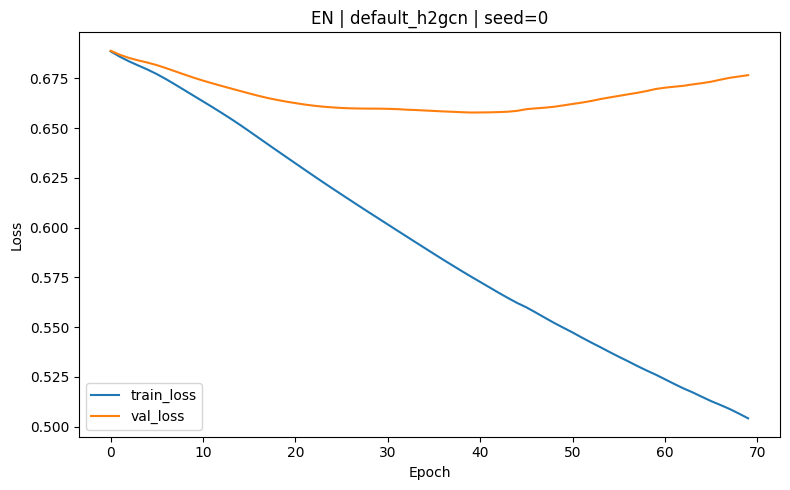

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default H2GCN on dataset: ES
  Seed 0 ...


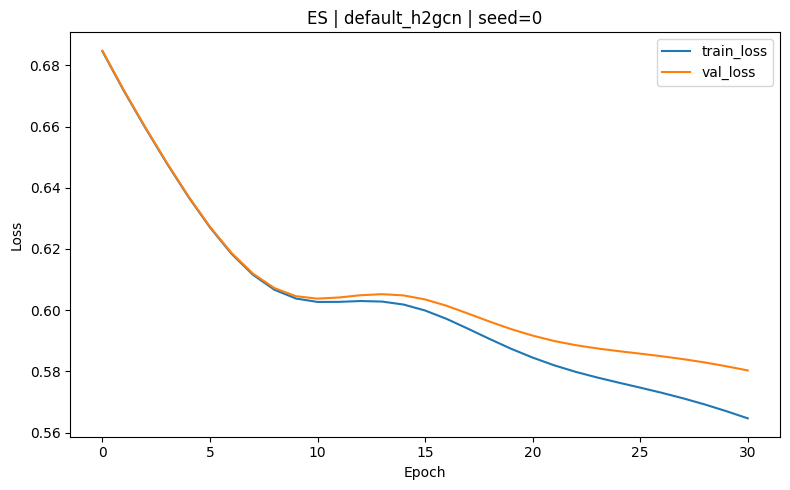

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default H2GCN on dataset: FR
  Seed 0 ...


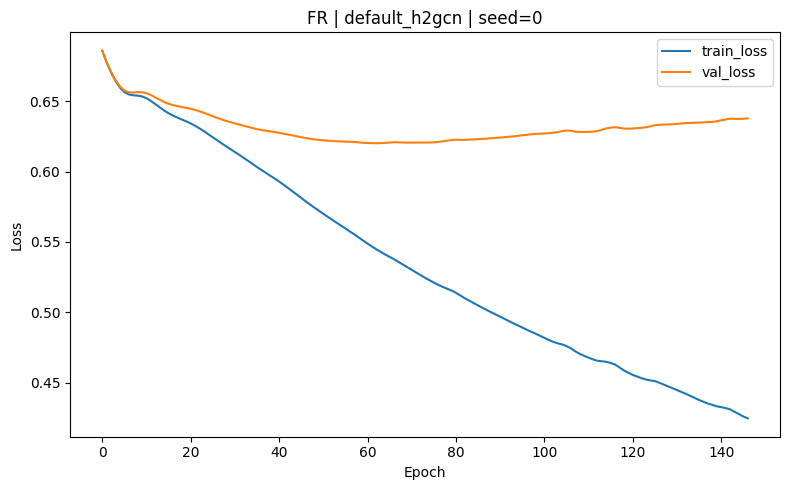

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default H2GCN on dataset: PT
  Seed 0 ...


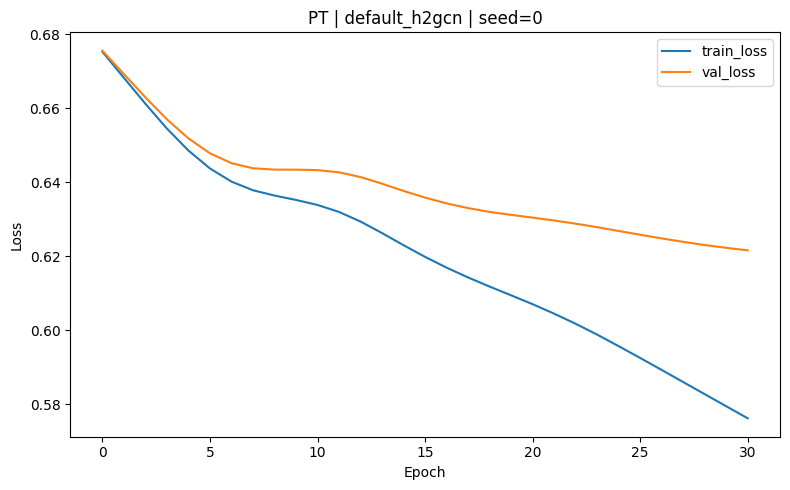

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default H2GCN on dataset: RU
  Seed 0 ...


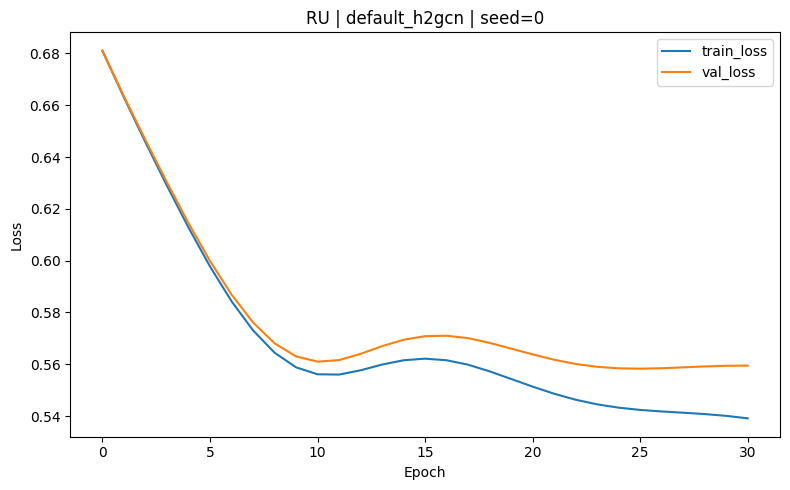

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...


,dataset,seed,run_name,hidden_dim,num_layers,dropout,learning_rate,weight_decay,max_epochs,patience,...,train_f1,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,best_state_dict_path
0,DE,0,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.807013,0.749595,0.752116,0.727677,0.642815,0.642927,0.817446,0.710432,0.708657,outputs/models/DE_default_h2gcn_seed0.pt
1,DE,1,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.817070,0.757987,0.744767,0.741868,0.645197,0.631502,0.836531,0.708723,0.719105,outputs/models/DE_default_h2gcn_seed1.pt
2,DE,2,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.794300,0.755328,0.765074,0.692932,0.632798,0.641767,0.794808,0.722034,0.732580,outputs/models/DE_default_h2gcn_seed2.pt
3,DE,3,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.794961,0.746774,0.756436,0.703022,0.635508,0.637041,0.790315,0.702422,0.730312,outputs/models/DE_default_h2gcn_seed3.pt
4,DE,4,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.805635,0.748377,0.747262,0.728889,0.642152,0.640297,0.814499,0.721387,0.705275,outputs/models/DE_default_h2gcn_seed4.pt
5,EN,0,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.753617,0.675121,0.663403,0.710874,0.612267,0.605921,0.792732,0.647402,0.631768,outputs/models/EN_default_h2gcn_seed0.pt
6,EN,1,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.749697,0.667890,0.639464,0.703095,0.610488,0.575104,0.781052,0.653141,0.622929,outputs/models/EN_default_h2gcn_seed1.pt
7,EN,2,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.748085,0.646809,0.674985,0.699851,0.582325,0.603532,0.779728,0.630464,0.659528,outputs/models/EN_default_h2gcn_seed2.pt
8,EN,3,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.759871,0.647713,0.659485,0.713734,0.592525,0.588845,0.792317,0.630470,0.650889,outputs/models/EN_default_h2gcn_seed3.pt
9,EN,4,default_h2gcn,64,2,0.5,0.001,0.0001,200,30,...,0.773711,0.686369,0.657402,0.731654,0.625064,0.591859,0.814734,0.670296,0.625555,outputs/models/EN_default_h2gcn_seed4.pt


Saved per-run results to: outputs/metrics/h2gcn_results.csv


In [9]:
# ============================================================
# Cell 8: Main experiment loop (default H2GCN baseline)
# ============================================================
default_results = []
representative_result = None

for dataset_name in DATASET_NAMES:
    data_obj = dataset_data[dataset_name]["data_obj"]

    print("=" * 80)
    print(f"Running default H2GCN on dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")
        result = train_one_run(
            data_obj=data_obj,
            splits=all_splits[dataset_name][seed],
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_h2gcn",
            save_training_curve=(seed == SEEDS[0])  # only save first seed per dataset
        )

        row = {k: v for k, v in result.items() if k != "history"}
        default_results.append(row)

        if representative_result is None:
            representative_result = result

default_results_df = pd.DataFrame(default_results).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(default_results_df.head(12))

default_results_path = os.path.join(METRICS_DIR, "h2gcn_results.csv")
default_results_df.to_csv(default_results_path, index=False)

print(f"Saved per-run results to: {default_results_path}")


## 9 - aggregate results

In [10]:
# ============================================================
# Cell 9: Aggregate default results
# ============================================================
# Macro F1 is the headline aggregated metric (matches MAIN_METRIC).
agg_df = (
    default_results_df
    .groupby("dataset", as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"],
        "test_roc_auc": ["mean", "std"],
        "val_macro_f1": ["mean", "std"],
        "elapsed_seconds": ["mean"]
    })
)

agg_df.columns = [
    "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std",
    "test_roc_auc_mean", "test_roc_auc_std",
    "val_macro_f1_mean", "val_macro_f1_std",
    "elapsed_seconds_mean"
]

display(agg_df)

agg_path = os.path.join(METRICS_DIR, "h2gcn_results_aggregated.csv")
agg_df.to_csv(agg_path, index=False)

print(f"Saved aggregated results to: {agg_path}")


,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_roc_auc_mean,test_roc_auc_std,val_macro_f1_mean,val_macro_f1_std,elapsed_seconds_mean
0,DE,0.638707,0.004593,0.753131,0.008047,0.675053,0.006559,0.719186,0.012324,0.639694,0.005271,114.094049
1,EN,0.593052,0.012417,0.658948,0.012839,0.603787,0.012632,0.638134,0.016204,0.604534,0.016986,66.254711
2,ES,0.418230,0.011242,0.052411,0.113392,0.661075,0.091554,0.465375,0.047171,0.424578,0.019023,19.666667
3,FR,0.548715,0.066241,0.427160,0.074154,0.590847,0.079588,0.579770,0.082587,0.545896,0.082616,100.824536
4,PT,0.497307,0.099421,0.272629,0.202478,0.616710,0.093438,0.507902,0.111836,0.521936,0.120439,20.380075
5,RU,0.460119,0.039595,0.112485,0.155675,0.699202,0.090918,0.492136,0.019473,0.448273,0.030240,18.082475


Saved aggregated results to: outputs/metrics/h2gcn_results_aggregated.csv


## 10 - plot default H2GCN results

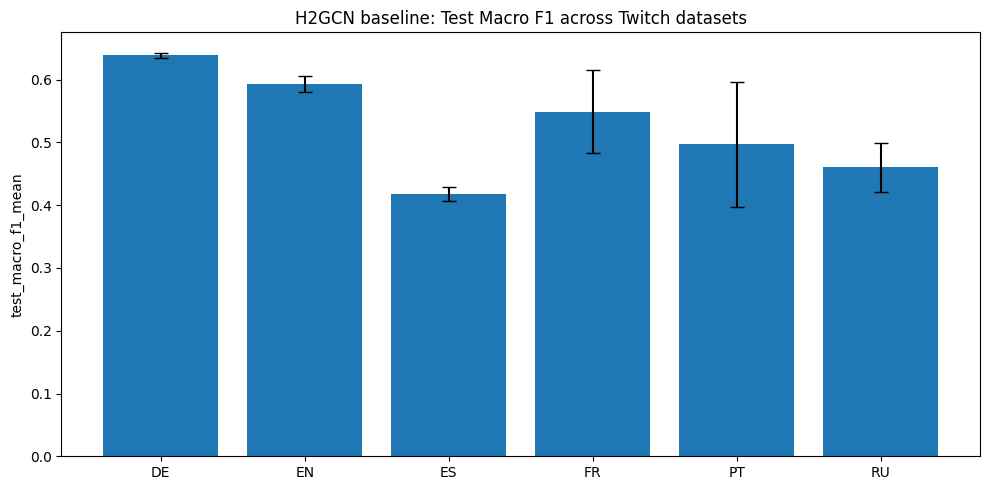

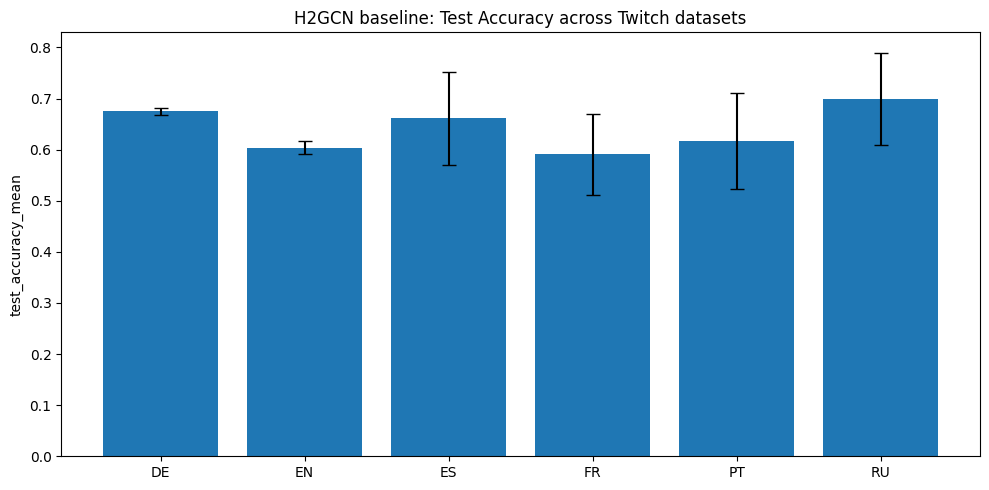

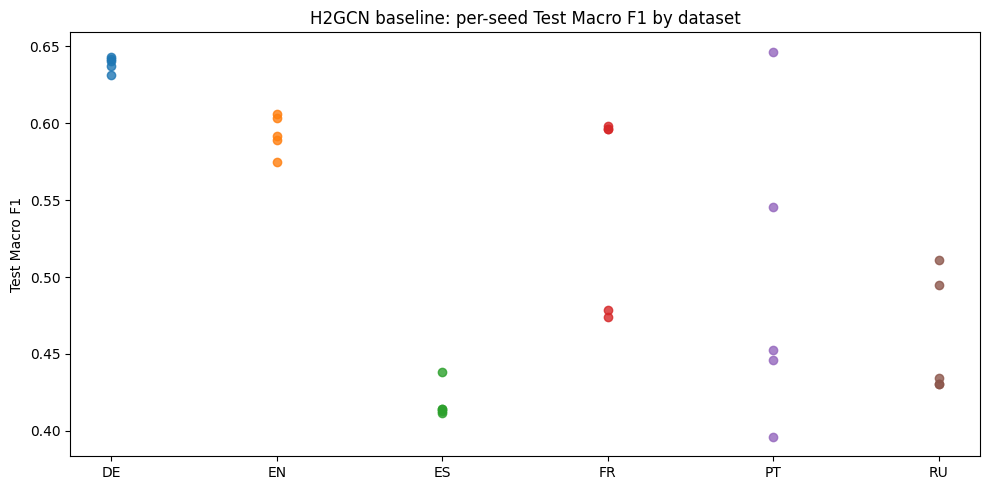

Saved default result plots.


In [11]:
# ============================================================
# Cell 10: Plots for default H2GCN results
# ============================================================
# Headline plot is Macro F1.
plot_bar_with_error(
    df=agg_df,
    metric_col="test_macro_f1_mean",
    std_col="test_macro_f1_std",
    title="H2GCN baseline: Test Macro F1 across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "h2gcn_test_macro_f1_barplot.png")
)

# Plot 2: Test accuracy mean +/- std across datasets (kept for context)
plot_bar_with_error(
    df=agg_df,
    metric_col="test_accuracy_mean",
    std_col="test_accuracy_std",
    title="H2GCN baseline: Test Accuracy across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "h2gcn_test_accuracy_barplot.png")
)

# Plot 3: Per-seed Macro F1 scatter by dataset
plt.figure(figsize=(10, 5))
for i, dataset_name in enumerate(DATASET_NAMES):
    vals = default_results_df.loc[default_results_df["dataset"] == dataset_name, "test_macro_f1"].values
    x = np.full_like(vals, fill_value=i, dtype=float)
    plt.scatter(x, vals, alpha=0.8)

plt.xticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
plt.ylabel("Test Macro F1")
plt.title("H2GCN baseline: per-seed Test Macro F1 by dataset")
plt.tight_layout()
scatter_path = os.path.join(FIGURES_DIR, "h2gcn_test_macro_f1_scatter.png")
plt.savefig(scatter_path, dpi=200)
plt.show()

print("Saved default result plots.")


## 11 - run ablations

In [12]:
# ============================================================
# Cell 11: H2GCN ablations
# ============================================================
# To keep runtime manageable, do ablations on a subset of seeds by default.
ABLATION_SEEDS = [0, 1, 2]

ablation_results = []

# -----------------------------
# Ablation A: hidden dimension
# -----------------------------
for hidden_dim in ABLATION_GRID["hidden_dim"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["hidden_dim"] = hidden_dim

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation hidden_dim={hidden_dim}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_hidden{hidden_dim}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "hidden_dim"
            row["ablation_value"] = hidden_dim
            ablation_results.append(row)

# -----------------------------
# Ablation B: number of propagation layers
# -----------------------------
for num_layers in ABLATION_GRID["num_layers"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["num_layers"] = num_layers

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation num_layers={num_layers}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_layers{num_layers}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "num_layers"
            row["ablation_value"] = num_layers
            ablation_results.append(row)

# -----------------------------
# Ablation C: dropout
# -----------------------------
for dropout in ABLATION_GRID["dropout"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["dropout"] = dropout

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation dropout={dropout}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_dropout{dropout}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "dropout"
            row["ablation_value"] = dropout
            ablation_results.append(row)

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["ablation_type", "ablation_value", "dataset", "seed"]
).reset_index(drop=True)

display(ablation_results_df.head(20))

ablation_results_path = os.path.join(METRICS_DIR, "h2gcn_ablation_results.csv")
ablation_results_df.to_csv(ablation_results_path, index=False)
print(f"Saved ablation results to: {ablation_results_path}")


[Ablation hidden_dim=32] dataset=DE, seed=0
[Ablation hidden_dim=32] dataset=DE, seed=1
[Ablation hidden_dim=32] dataset=DE, seed=2
[Ablation hidden_dim=32] dataset=EN, seed=0
[Ablation hidden_dim=32] dataset=EN, seed=1
[Ablation hidden_dim=32] dataset=EN, seed=2
[Ablation hidden_dim=32] dataset=ES, seed=0
[Ablation hidden_dim=32] dataset=ES, seed=1
[Ablation hidden_dim=32] dataset=ES, seed=2
[Ablation hidden_dim=32] dataset=FR, seed=0
[Ablation hidden_dim=32] dataset=FR, seed=1
[Ablation hidden_dim=32] dataset=FR, seed=2
[Ablation hidden_dim=32] dataset=PT, seed=0
[Ablation hidden_dim=32] dataset=PT, seed=1
[Ablation hidden_dim=32] dataset=PT, seed=2
[Ablation hidden_dim=32] dataset=RU, seed=0
[Ablation hidden_dim=32] dataset=RU, seed=1
[Ablation hidden_dim=32] dataset=RU, seed=2
[Ablation hidden_dim=64] dataset=DE, seed=0
[Ablation hidden_dim=64] dataset=DE, seed=1
[Ablation hidden_dim=64] dataset=DE, seed=2
[Ablation hidden_dim=64] dataset=EN, seed=0
[Ablation hidden_dim=64] dataset

,dataset,seed,run_name,hidden_dim,num_layers,dropout,learning_rate,weight_decay,max_epochs,patience,...,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,best_state_dict_path,ablation_type,ablation_value
0,DE,0,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.749798,0.735169,0.639670,0.640406,0.824077,0.704804,0.700651,outputs/models/DE_ablation_dropout0.0_seed0.pt,dropout,0.0
1,DE,1,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.744300,0.741488,0.641411,0.638519,0.830910,0.701397,0.711445,outputs/models/DE_ablation_dropout0.0_seed1.pt,dropout,0.0
2,DE,2,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.749794,0.781166,0.643392,0.652999,0.869509,0.706187,0.713651,outputs/models/DE_ablation_dropout0.0_seed2.pt,dropout,0.0
3,EN,0,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.650155,0.731195,0.605215,0.596702,0.818594,0.642638,0.629842,outputs/models/EN_ablation_dropout0.0_seed0.pt,dropout,0.0
4,EN,1,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.650560,0.685676,0.605617,0.568570,0.767411,0.650566,0.616385,outputs/models/EN_ablation_dropout0.0_seed1.pt,dropout,0.0
5,EN,2,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.669082,0.731041,0.581055,0.605444,0.810075,0.629264,0.653865,outputs/models/EN_ablation_dropout0.0_seed2.pt,dropout,0.0
6,ES,0,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.000000,0.414286,0.414358,0.414358,0.570948,0.539477,0.513457,outputs/models/ES_ablation_dropout0.0_seed0.pt,dropout,0.0
7,ES,1,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.006920,0.424342,0.414826,0.412117,0.553736,0.471465,0.458670,outputs/models/ES_ablation_dropout0.0_seed1.pt,dropout,0.0
8,ES,2,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.000000,0.414286,0.414358,0.414358,0.529213,0.458274,0.491256,outputs/models/ES_ablation_dropout0.0_seed2.pt,dropout,0.0
9,FR,0,ablation_dropout0.0,64,2,0.0,0.001,0.0001,200,30,...,0.423077,0.803475,0.605175,0.577460,0.898506,0.637381,0.628754,outputs/models/FR_ablation_dropout0.0_seed0.pt,dropout,0.0


Saved ablation results to: outputs/metrics/h2gcn_ablation_results.csv


## 12 - summarize and plot results

,ablation_type,ablation_value,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std
0,dropout,0.0,DE,0.643975,0.007872,0.747964,0.003173,0.674386,0.005298
1,dropout,0.0,EN,0.590239,0.019268,0.656599,0.010813,0.601216,0.015935
2,dropout,0.0,ES,0.413611,0.001294,0.002307,0.003996,0.702151,0.009312
3,dropout,0.0,FR,0.554895,0.038788,0.422898,0.004718,0.598271,0.064315
4,dropout,0.0,PT,0.536299,0.060059,0.367113,0.051141,0.602263,0.085260
5,dropout,0.0,RU,0.461560,0.054404,0.110256,0.190970,0.704295,0.087557
6,dropout,0.2,DE,0.645362,0.008979,0.751251,0.010460,0.677018,0.010635
7,dropout,0.2,EN,0.589216,0.020215,0.648882,0.013950,0.597943,0.018677
8,dropout,0.2,ES,0.413740,0.001069,0.002315,0.004009,0.702509,0.008691
9,dropout,0.2,FR,0.555213,0.047405,0.429333,0.018456,0.598525,0.079051


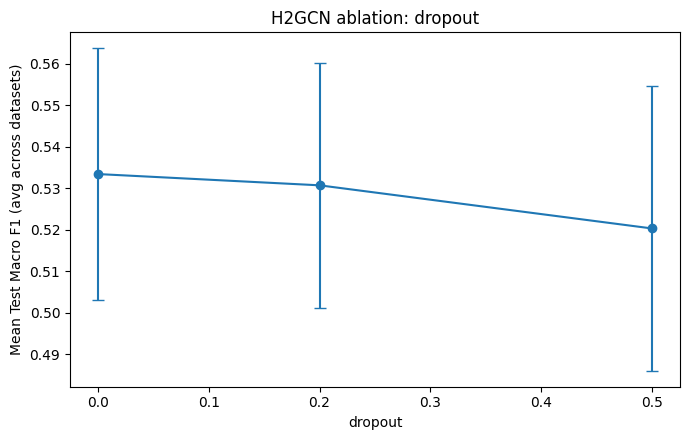

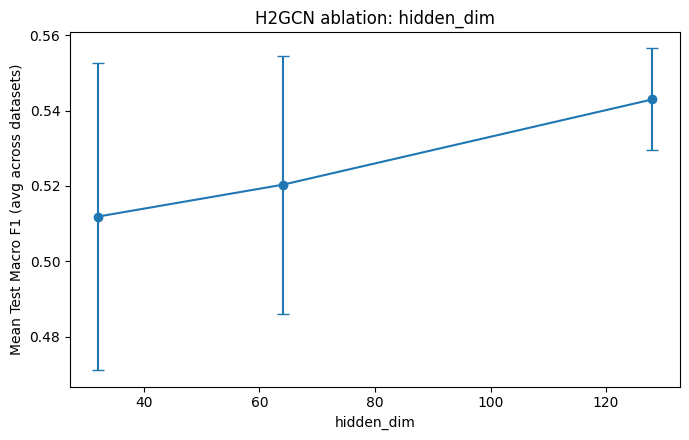

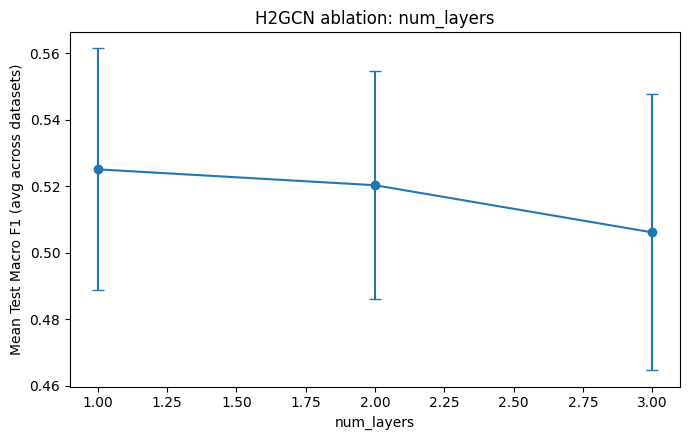

Saved ablation summary to: outputs/metrics/h2gcn_ablation_summary.csv


In [13]:
# ============================================================
# Cell 12: Summarize and plot ablation results
# ============================================================
# Ablation plot uses Macro F1 (matches headline metric).
ablation_summary_df = (
    ablation_results_df
    .groupby(["ablation_type", "ablation_value", "dataset"], as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"]
    })
)

ablation_summary_df.columns = [
    "ablation_type", "ablation_value", "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std"
]

display(ablation_summary_df.head(20))

ablation_summary_path = os.path.join(METRICS_DIR, "h2gcn_ablation_summary.csv")
ablation_summary_df.to_csv(ablation_summary_path, index=False)

# One plot per ablation type: average across datasets, on Macro F1.
for ablation_type in ablation_summary_df["ablation_type"].unique():
    sub = ablation_summary_df[ablation_summary_df["ablation_type"] == ablation_type].copy()

    collapsed = (
        sub.groupby("ablation_value", as_index=False)
        .agg({
            "test_macro_f1_mean": "mean",
            "test_macro_f1_std": "mean"
        })
        .sort_values("ablation_value")
    )

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        collapsed["ablation_value"].values,
        collapsed["test_macro_f1_mean"].values,
        yerr=collapsed["test_macro_f1_std"].values,
        marker="o",
        capsize=4
    )
    plt.xlabel(ablation_type)
    plt.ylabel("Mean Test Macro F1 (avg across datasets)")
    plt.title(f"H2GCN ablation: {ablation_type}")
    plt.tight_layout()

    fig_path = os.path.join(FIGURES_DIR, f"h2gcn_ablation_{ablation_type}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

print(f"Saved ablation summary to: {ablation_summary_path}")


## 13 - final summary

In [14]:
# ============================================================
# Cell 13: Final summary table
# ============================================================
# Best run per dataset is picked by val_macro_f1 (then test_macro_f1
# as a tiebreaker), matching the headline metric.
best_default_runs_df = (
    default_results_df
    .sort_values(["dataset", "val_macro_f1", "test_macro_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

final_summary_df = best_default_runs_df[[
    "dataset",
    "seed",
    "hidden_dim",
    "num_layers",
    "dropout",
    "learning_rate",
    "weight_decay",
    "best_epoch",
    "val_macro_f1",
    "test_accuracy",
    "test_f1",
    "test_macro_f1",
    "test_roc_auc"
]].copy()

display(final_summary_df)

final_summary_path = os.path.join(METRICS_DIR, "h2gcn_final_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print(f"Saved final summary to: {final_summary_path}")
print("Notebook finished successfully.")


,dataset,seed,hidden_dim,num_layers,dropout,learning_rate,weight_decay,best_epoch,val_macro_f1,test_accuracy,test_f1,test_macro_f1,test_roc_auc
0,DE,1,64,2,0.5,0.001,0.0001,65,0.645197,0.666316,0.744767,0.631502,0.719105
1,EN,4,64,2,0.5,0.001,0.0001,47,0.625064,0.602384,0.657402,0.591859,0.625555
2,ES,3,64,2,0.5,0.001,0.0001,0,0.458463,0.497849,0.255183,0.438216,0.419506
3,FR,0,64,2,0.5,0.001,0.0001,116,0.616180,0.646072,0.460465,0.598564,0.646207
4,PT,2,64,2,0.5,0.001,0.0001,112,0.658929,0.637076,0.341232,0.545391,0.590456
5,RU,3,64,2,0.5,0.001,0.0001,0,0.501244,0.687571,0.217143,0.510993,0.504897


Saved final summary to: outputs/metrics/h2gcn_final_summary.csv
Notebook finished successfully.


In [16]:
from google.colab import files
!zip -r h2gcn_outputs.zip outputs/

  adding: outputs/ (stored 0%)
  adding: outputs/splits/ (stored 0%)
  adding: outputs/splits/RU_seed3_splits.json (deflated 75%)
  adding: outputs/splits/ES_seed0_splits.json (deflated 75%)
  adding: outputs/splits/ES_seed1_splits.json (deflated 75%)
  adding: outputs/splits/ES_seed3_splits.json (deflated 75%)
  adding: outputs/splits/DE_seed2_splits.json (deflated 75%)
  adding: outputs/splits/DE_seed3_splits.json (deflated 75%)
  adding: outputs/splits/EN_seed0_splits.json (deflated 75%)
  adding: outputs/splits/DE_seed4_splits.json (deflated 75%)
  adding: outputs/splits/FR_seed4_splits.json (deflated 75%)
  adding: outputs/splits/FR_seed3_splits.json (deflated 75%)
  adding: outputs/splits/DE_seed1_splits.json (deflated 75%)
  adding: outputs/splits/ES_seed4_splits.json (deflated 75%)
  adding: outputs/splits/FR_seed0_splits.json (deflated 75%)
  adding: outputs/splits/RU_seed4_splits.json (deflated 75%)
  adding: outputs/splits/RU_seed2_splits.json (deflated 75%)
  adding: output